In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving stock_features.csv to stock_features.csv


In [ ]:
df = pd.read_csv('stock_features.csv', sep=';')

df['date'] = pd.to_datetime(df['date'], dayfirst=True)

df = df.sort_values(['ticker', 'date']).reset_index(drop=True)

print("Số dòng:", len(df))
print("Số ticker:", df["ticker"].nunique())

print(df.columns.tolist())

Số dòng: 4690
Số ticker: 14
['ticker', 'date', 'open', 'high', 'low', 'close', 'volume', 'return', 'abs_Return', 'range', 'Volume_Mean_20', 'Volume_Std_20', 'Relative_Volume', 'Volume_Z', 'Volatility_20']


In [ ]:
mwg = df[
    df["ticker"] == "MWG"
].copy()

mwg = mwg.sort_values(
    "date"
).reset_index(drop=True)

print("Số phiên MWG:", len(mwg))

mwg.head()

Số phiên MWG: 335


,ticker,date,open,high,low,close,volume,return,abs_Return,range,Volume_Mean_20,Volume_Std_20,Relative_Volume,Volume_Z,Volatility_20
0,MWG,2025-05-05,59.12,59.21,59.02,59.21,5099700,NaN,NaN,0.003214,NaN,NaN,NaN,NaN,NaN
1,MWG,2025-05-06,59.21,59.40,58.34,58.73,4110300,-0.008107,0.008107,0.017902,NaN,NaN,NaN,NaN,NaN
2,MWG,2025-05-07,58.14,58.73,57.37,58.34,7742800,-0.006641,0.006641,0.023392,NaN,NaN,NaN,NaN,NaN
3,MWG,2025-05-08,58.34,58.53,57.17,58.53,9463100,0.003257,0.003257,0.023312,NaN,NaN,NaN,NaN,NaN
4,MWG,2025-05-09,58.53,59.21,58.34,58.63,4780000,0.001709,0.001709,0.014864,NaN,NaN,NaN,NaN,NaN


In [ ]:
features = [
    "abs_Return",
    "range",
    "Relative_Volume",
    "Volatility_20"
]

In [ ]:
mwg[
    ["date"] + features
].head(30)

,date,abs_Return,range,Relative_Volume,Volatility_20
0,2025-05-05,NaN,0.003214,NaN,NaN
1,2025-05-06,0.008107,0.017902,NaN,NaN
2,2025-05-07,0.006641,0.023392,NaN,NaN
3,2025-05-08,0.003257,0.023312,NaN,NaN
4,2025-05-09,0.001709,0.014864,NaN,NaN
5,2025-05-12,0.006652,0.013238,NaN,NaN
6,2025-05-13,0.044392,0.044276,NaN,NaN
7,2025-05-14,0.007787,0.010978,NaN,NaN
8,2025-05-15,0.004829,0.024791,NaN,NaN
9,2025-05-16,0.007690,0.015660,NaN,NaN


In [ ]:
model_data = mwg[
    ["date", "close", "volume"] + features
].dropna().copy()

In [ ]:
print("Số phiên MWG ban đầu:", len(mwg))
print("Số phiên đủ dữ liệu cho KNN:", len(model_data))

model_data.head()

Số phiên MWG ban đầu: 335
Số phiên đủ dữ liệu cho KNN: 314


,date,close,volume,abs_Return,range,Relative_Volume,Volatility_20
21,2025-06-03,60.57,6563500,0.022969,0.029556,0.7466774361439205,0.014672
22,2025-06-04,59.50,6679500,0.017666,0.027067,0.7494164380195749,0.015386
23,2025-06-05,59.89,5366600,0.006555,0.019760,0.6057267852325737,0.015888
24,2025-06-06,58.73,6292000,0.019369,0.014646,0.7269832448386443,0.015928
25,2025-06-09,58.73,7249100,0.000000,0.013281,0.8303147168933899,0.016582


In [ ]:
model_data[features].isnull().sum()

,0
abs_Return,0
range,0
Relative_Volume,0
Volatility_20,0


In [ ]:
scaler = StandardScaler()

# The error 'ValueError: could not convert string to float: '12.033.570.869.523.800'' indicates that the 'Relative_Volume'
# column contains strings that cannot be directly converted to float due to incorrect formatting (e.g., using '.' as
# a thousands separator instead of a decimal point, or having multiple decimal points).
# We need to clean this column by removing the thousands separators and then converting it to a numeric type.

# Ensure 'Relative_Volume' is a string type, remove all '.' characters, and then convert to float.
model_data['Relative_Volume'] = model_data['Relative_Volume'].astype(str).str.replace('.', '', regex=False)
model_data['Relative_Volume'] = pd.to_numeric(model_data['Relative_Volume'], errors='coerce')

# Drop any rows where 'Relative_Volume' might have become NaN due to failed conversion
# (e.g., if there were other non-numeric strings besides the thousands separator issue).
model_data.dropna(subset=['Relative_Volume'], inplace=True)

X_scaled = scaler.fit_transform(
    model_data[features]
)

In [ ]:
X_scaled[:5]

array([[ 0.49424993,  0.22076045, -0.24048715, -0.96972024],
       [ 0.13089108,  0.0383432 , -0.23679371, -0.85660867],
       [-0.63033781, -0.49718801, -0.4305535 , -0.77695341],
       [ 0.2475897 , -0.87198537, -0.26704398, -0.77051692],
       [-1.07940786, -0.97205529, -0.1277056 , -0.66689811]])

In [ ]:
k = 5

In [ ]:
knn = NearestNeighbors(
    n_neighbors=k + 1
)

knn.fit(X_scaled)

distances, indices = knn.kneighbors(
    X_scaled
)

In [ ]:
distances[0]

array([0.        , 0.11548906, 0.42203504, 0.43449715, 0.52997579,
       0.55765446])

In [ ]:
model_data["KNN_Score"] = (
    distances[:, 1:].mean(axis=1)
)

In [ ]:
model_data[
    [
        "date",
        "abs_Return",
        "range",
        "Relative_Volume",
        "Volatility_20",
        "KNN_Score"
    ]
].head(20)

,date,abs_Return,range,Relative_Volume,Volatility_20,KNN_Score
21,2025-06-03,0.022969,0.029556,7466774361439205,0.014672,0.411930
22,2025-06-04,0.017666,0.027067,7494164380195749,0.015386,0.369506
23,2025-06-05,0.006555,0.019760,6057267852325737,0.015888,0.344470
24,2025-06-06,0.019369,0.014646,7269832448386443,0.015928,0.520624
25,2025-06-09,0.000000,0.013281,8303147168933899,0.016582,0.361660
26,2025-06-10,0.016516,0.037831,12033570869523800,0.016512,0.668249
27,2025-06-11,0.006365,0.011390,5021536858371843,0.013450,0.328808
28,2025-06-12,0.025965,0.022416,12980651991966200,0.013402,0.651171
29,2025-06-13,0.004867,0.025468,10767445872877300,0.014704,0.418705
30,2025-06-16,0.017607,0.027142,9977074900598202,0.014645,0.367445


In [ ]:
threshold = model_data[
    "KNN_Score"
].quantile(0.95)

print(
    "KNN threshold:",
    threshold
)

KNN threshold: 1.3881250696115601


In [ ]:
model_data["KNN_Anomaly"] = (
    model_data["KNN_Score"] >= threshold
).astype(int)

In [ ]:
print(
    "Tổng phiên đưa vào KNN:",
    len(model_data)
)

print(
    "Số anomaly:",
    model_data["KNN_Anomaly"].sum()
)

print(
    "Tỷ lệ:",
    round(
        model_data["KNN_Anomaly"].mean() * 100,
        2
    ),
    "%"
)

Tổng phiên đưa vào KNN: 314
Số anomaly: 16
Tỷ lệ: 5.1 %


In [ ]:
top10 = (
    model_data
    .sort_values(
        "KNN_Score",
        ascending=False
    )
    .head(10)
)

top10[
    [
        "date",
        "close",
        "volume",
        "abs_Return",
        "range",
        "Relative_Volume",
        "Volatility_20",
        "KNN_Score"
    ]
]

,date,close,volume,abs_Return,range,Relative_Volume,Volatility_20,KNN_Score
211,2026-03-09,75.82,4983800,0.068894,0.000000,5630521725376777,0.017848,3.280313
305,2026-07-22,69.52,13474000,0.069842,0.071046,35985412474177300,0.013731,2.939761
118,2025-10-20,79.66,14226400,0.042548,0.093031,18816197399189400,0.013945,2.629374
61,2025-07-29,65.58,18358200,0.051215,0.054109,24055821267116500,0.007351,2.236959
296,2026-07-09,77.30,1582900,0.003738,0.008938,38324324651506253,0.015488,2.067942
221,2026-03-23,73.06,17473900,0.069062,0.050000,19452447322016900,0.031776,1.927551
264,2026-05-26,77.30,2518800,0.002452,0.013884,42750978267234346,0.016616,1.724780
240,2026-04-17,85.57,15089000,0.068957,0.053363,22739517314599900,0.027307,1.689221
233,2026-04-08,80.64,10192500,0.050000,0.026084,13568426202338200,0.030808,1.582577
137,2025-11-14,80.15,3951700,0.016229,0.035261,49955249238984234,0.025269,1.579436


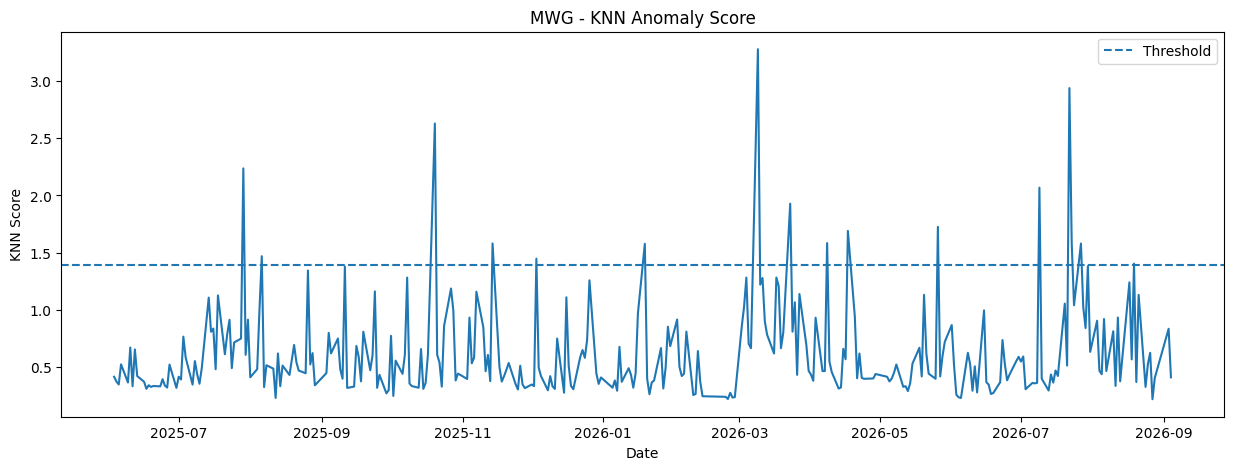

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(
    model_data["date"],
    model_data["KNN_Score"]
)

plt.axhline(
    threshold,
    linestyle="--",
    label="Threshold"
)

plt.xlabel("Date")
plt.ylabel("KNN Score")
plt.title("MWG - KNN Anomaly Score")

plt.legend()

plt.show()

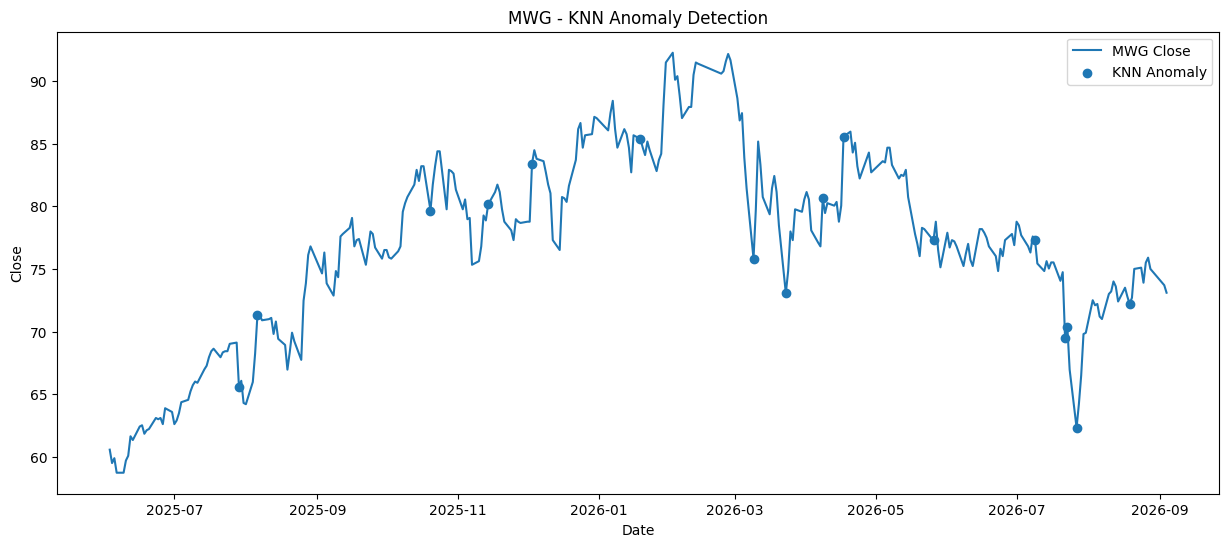

In [ ]:
plt.figure(figsize=(15, 6))

plt.plot(
    model_data["date"],
    model_data["close"],
    label="MWG Close"
)

anomalies = model_data[
    model_data["KNN_Anomaly"] == 1
]

plt.scatter(
    anomalies["date"],
    anomalies["close"],
    marker="o",
    label="KNN Anomaly"
)

plt.xlabel("Date")
plt.ylabel("Close")
plt.title("MWG - KNN Anomaly Detection")

plt.legend()

plt.show()

In [ ]:
anomalies[
    [
        "date",
        "abs_Return",
        "range",
        "Relative_Volume",
        "Volatility_20",
        "KNN_Score"
    ]
].sort_values(
    "KNN_Score",
    ascending=False
)

,date,abs_Return,range,Relative_Volume,Volatility_20,KNN_Score
211,2026-03-09,0.068894,0.000000,5630521725376777,0.017848,3.280313
305,2026-07-22,0.069842,0.071046,35985412474177300,0.013731,2.939761
118,2025-10-20,0.042548,0.093031,18816197399189400,0.013945,2.629374
61,2025-07-29,0.051215,0.054109,24055821267116500,0.007351,2.236959
296,2026-07-09,0.003738,0.008938,38324324651506253,0.015488,2.067942
221,2026-03-23,0.069062,0.050000,19452447322016900,0.031776,1.927551
264,2026-05-26,0.002452,0.013884,42750978267234346,0.016616,1.724780
240,2026-04-17,0.068957,0.053363,22739517314599900,0.027307,1.689221
233,2026-04-08,0.050000,0.026084,13568426202338200,0.030808,1.582577
137,2025-11-14,0.016229,0.035261,49955249238984234,0.025269,1.579436


In [ ]:
import os

os.makedirs(
    "../results",
    exist_ok=True
)

In [ ]:
model_data.to_csv(
    "../results/knn_v0_mwg.csv",
    index=False
)

In [ ]:
check = pd.read_csv(
    "../results/knn_v0_mwg.csv"
)

check.head()

,date,close,volume,abs_Return,range,Relative_Volume,Volatility_20,KNN_Score,KNN_Anomaly
0,2025-06-03,60.57,6563500,0.022969,0.029556,7466774361439205,0.014672,0.411930,0
1,2025-06-04,59.50,6679500,0.017666,0.027067,7494164380195749,0.015386,0.369506,0
2,2025-06-05,59.89,5366600,0.006555,0.019760,6057267852325737,0.015888,0.344470,0
3,2025-06-06,58.73,6292000,0.019369,0.014646,7269832448386443,0.015928,0.520624,0
4,2025-06-09,58.73,7249100,0.000000,0.013281,8303147168933899,0.016582,0.361660,0
